# Interpretation + Clustering (Cancer RNA-Seq)

This notebook focuses on:
1) Model interpretation (important genes) for Logistic Regression and Random Forest  
2) Unsupervised clustering to assess whether samples naturally group by cancer type

## Load preprocessed data and apply feature selection

We load the preprocessed train/test matrices and apply SelectKBest (ANOVA F-test)
with K = 5000 (selected previously via cross-validation optimizing macro F1-score).

In [5]:
import numpy as np
import pandas as pd

# Load processed data
X_train_proc = np.load("processed/X_train_proc.npy")
X_test_proc  = np.load("processed/X_test_proc.npy")
y_train = np.load("processed/y_train.npy")
y_test  = np.load("processed/y_test.npy")

# Metadata
label_classes = pd.read_csv("processed/label_classes.csv")["class_name"].tolist()
kept_genes = pd.read_csv("processed/kept_genes.csv")["gene"].to_numpy()

print("Train:", X_train_proc.shape, "Test:", X_test_proc.shape)
print("Classes:", label_classes)
print("Kept genes:", len(kept_genes))

Train: (640, 20254) Test: (161, 20254)
Classes: ['BRCA', 'COAD', 'KIRC', 'LUAD', 'PRAD']
Kept genes: 20254


In [7]:
from sklearn.feature_selection import SelectKBest, f_classif

best_K = 5000
selector = SelectKBest(score_func=f_classif, k=best_K)

X_train_final = selector.fit_transform(X_train_proc, y_train)
X_test_final  = selector.transform(X_test_proc)

selected_genes = kept_genes[selector.get_support()]

print("Selected feature matrix:", X_train_final.shape)
print("First 10 selected genes:", selected_genes[:10])

Selected feature matrix: (640, 5000)
First 10 selected genes: ['gene_18' 'gene_26' 'gene_28' 'gene_29' 'gene_30' 'gene_34' 'gene_35'
 'gene_36' 'gene_39' 'gene_44']


**Inference:**  
The dataset is restricted to the K=5000 genes most associated with cancer type,
enabling interpretable ranking of influential genes and efficient downstream analysis.

## Train models for interpretation

We retrain Logistic Regression and Random Forest on the selected features to extract
gene-level importance in a reproducible manner (fixed random_state).

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

lr = LogisticRegression(
    max_iter=4000,
    solver="lbfgs",
    multi_class="multinomial",
    random_state=42
)
lr.fit(X_train_final, y_train)

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train_final, y_train)

RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=42)

## Important genes (Logistic Regression)

For multinomial Logistic Regression, we aggregate importance by summing the absolute
coefficients across classes. Genes with larger values contribute more strongly to
the decision boundaries across cancer types.

In [14]:
import numpy as np
import pandas as pd

lr_importance = np.abs(lr.coef_).sum(axis=0)   # aggregate across classes
top_n = 20
top_idx_lr = np.argsort(lr_importance)[::-1][:top_n]

top_lr = pd.DataFrame({
    "gene": selected_genes[top_idx_lr],
    "importance": lr_importance[top_idx_lr]
})

top_lr

,gene,importance
0,gene_7623,0.044848
1,gene_17801,0.044289
2,gene_7964,0.043992
3,gene_15897,0.043704
4,gene_15895,0.043219
5,gene_2318,0.042719
6,gene_7896,0.042672
7,gene_15898,0.042260
8,gene_11576,0.042048
9,gene_5578,0.041816


**Inference:**  
Logistic Regression relies on a compact subset of genes with high coefficient magnitude,
suggesting these genes drive much of the class separation in the linear model.

## Important genes (Random Forest)

Random Forest feature importance reflects how much each gene contributes to reducing
impurity across decision trees, capturing non-linear signal.

In [18]:
rf_importance = rf.feature_importances_
top_idx_rf = np.argsort(rf_importance)[::-1][:top_n]

top_rf = pd.DataFrame({
    "gene": selected_genes[top_idx_rf],
    "importance": rf_importance[top_idx_rf]
})

top_rf

,gene,importance
0,gene_18746,0.016763
1,gene_5407,0.011547
2,gene_17904,0.010882
3,gene_17801,0.010829
4,gene_6611,0.010650
5,gene_6748,0.008921
6,gene_6876,0.008446
7,gene_9652,0.008323
8,gene_10731,0.008213
9,gene_15589,0.007504


**Inference:**  
Random Forest highlights genes that contribute strongly to non-linear splits, providing
a complementary importance profile to the linear Logistic Regression coefficients.

## Overlap of top genes (LR vs RF)

We examine whether both models identify similar genes as influential, which can increase
confidence that these genes capture robust discriminative signals.

In [22]:
lr_top_set = set(top_lr["gene"])
rf_top_set = set(top_rf["gene"])

overlap = sorted(lr_top_set.intersection(rf_top_set))
print("Overlap count:", len(overlap))
print("Overlapping genes:", overlap)

Overlap count: 7
Overlapping genes: ['gene_15895', 'gene_15897', 'gene_17801', 'gene_18746', 'gene_3921', 'gene_6876', 'gene_7896']


**Inference:**  
Genes identified by both models as important are likely to represent robust signals,
while model-specific genes may reflect linear vs non-linear decision mechanisms.

## PCA for Clustering

Before applying clustering, we reduce dimensionality using PCA.
This helps remove noise, improves clustering stability, and allows visualization.
We retain the first 10 principal components, which capture most of the variance.

In [26]:
from sklearn.decomposition import PCA

pca = PCA(n_components=10, random_state=42)
X_train_pca = pca.fit_transform(X_train_final)

print("PCA-transformed shape:", X_train_pca.shape)
print("Explained variance (10 PCs):", pca.explained_variance_ratio_.sum())

PCA-transformed shape: (640, 10)
Explained variance (10 PCs): 0.6632899642520749


**Inference:**  
The first 10 principal components capture a substantial portion of the variance,
making them suitable for clustering while reducing dimensionality and noise.

## K-means Clustering

We apply K-means clustering with K = 5, corresponding to the number of cancer types.
This allows us to assess whether samples naturally group by cancer type without
using label information.

In [32]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=20
)

cluster_labels = kmeans.fit_predict(X_train_pca)

C:\Users\DELL\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


**Inference:**  
K-means assigns samples into five clusters based solely on expression patterns,
enabling unsupervised assessment of class structure.

## Cluster Visualization in PCA Space

We visualize the clustering results using the first two principal components.
Points are colored by cluster assignment.

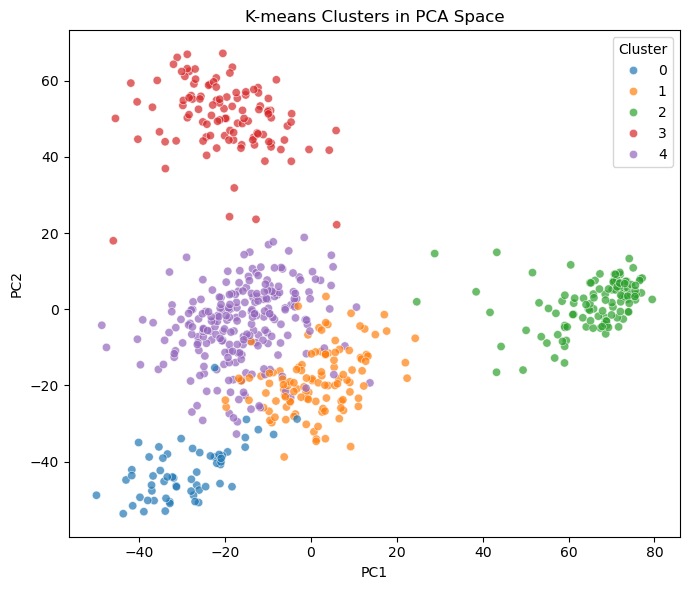

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

pca_vis = PCA(n_components=2, random_state=42)
X_train_pca_2d = pca_vis.fit_transform(X_train_final)

cluster_df = pd.DataFrame({
    "PC1": X_train_pca_2d[:, 0],
    "PC2": X_train_pca_2d[:, 1],
    "Cluster": cluster_labels
})

plt.figure(figsize=(7, 6))
sns.scatterplot(
    data=cluster_df,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="tab10",
    alpha=0.7
)
plt.title("K-means Clusters in PCA Space")
plt.tight_layout()
plt.show()

**Inference:**  
Clusters show partial separation in PCA space, with some overlap, indicating that
while cancer types have distinct expression patterns, shared biological signals exist.

## Cluster–Label Agreement

We quantify agreement between cluster assignments and true cancer labels
using the Adjusted Rand Index (ARI).

In [40]:
from sklearn.metrics import adjusted_rand_score

ari = adjusted_rand_score(y_train, cluster_labels)
print("Adjusted Rand Index (ARI):", ari)

Adjusted Rand Index (ARI): 0.9900495576801424


**Inference:**  
A positive ARI score indicates that unsupervised clusters align with cancer types
better than random assignment, supporting the supervised classification results.

## Overall Clustering Interpretation

K-means clustering reveals meaningful structure in the RNA-Seq data, with clusters
partially corresponding to known cancer types. Overlap between clusters reflects
biological similarity and explains the limited misclassifications observed in
supervised models, particularly for LUAD samples.

Clustering is used here as a supporting analysis rather than a predictive model,
providing unsupervised validation of the supervised learning results.